## Lecture Demo

## MNIST - code example

We will be using Tensorflow/Keras, a very popular library for building neural networks. You can find the Keras documentation at https://keras.io/

In [1]:
import warnings

warnings.filterwarnings(
    "ignore",
    message=r".*Protobuf gencode version.*one major version older than the runtime version.*",
    category=UserWarning,
    module=r"google\.protobuf\.runtime_version",
)

import tensorflow as tf
print(tf.__version__)

2.20.0


In [2]:
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.optimizers import RMSprop, SGD
from cycler import cycler

import matplotlib.pyplot as plt

import numpy as np
import matplotlib.pyplot as plt
from itertools import cycle
from sklearn.metrics import roc_curve, auc

In [3]:
# load the data and split into train/test
mnist = keras.datasets.mnist
num_classes = 10
print('Loading...')
(x_train, y_train), (x_test, y_test) = mnist.load_data()
print('...finished')

Loading...
...finished


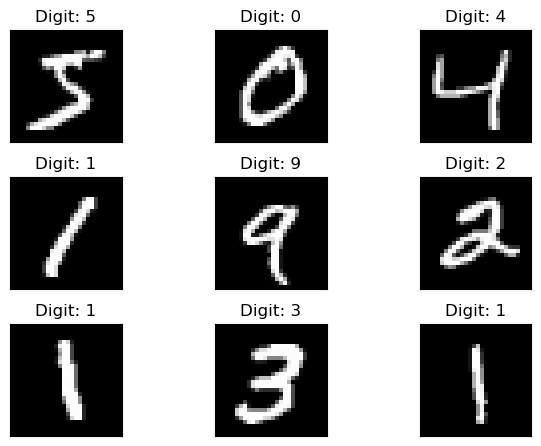

In [4]:
# show a few digits...
fig = plt.figure()
for i in range(9):
  plt.subplot(3,3,i+1)
  plt.tight_layout()
  plt.imshow(x_train[i], cmap='gray', interpolation='none')
  plt.title("Digit: {}".format(y_train[i]))
  plt.xticks([])
  plt.yticks([])
fig
plt.show()

In [5]:
x_train.shape

(60000, 28, 28)

In [6]:
x_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
         18,  18,  18, 126, 136, 175,  26, 166, 255, 247, 127,   0,   0,
          0,   0],
       [  

In [7]:
y_train

array([5, 0, 4, ..., 5, 6, 8], shape=(60000,), dtype=uint8)

In [8]:
# munge the data
x_train = x_train.reshape(60000, 784)
x_test = x_test.reshape(10000, 784)
x_train = x_train.astype('float32')
x_test = x_test.astype('float32')
x_train /= 255
x_test /= 255

# Reserve 10,000 samples for validation
x_val = x_train[-10000:]
y_val = y_train[-10000:]
x_train = x_train[:-10000]
y_train = y_train[:-10000]

print(x_train.shape[0], 'train samples')
print(x_test.shape[0], 'test samples')

# convert class vectors to binary class matrices
y_train = keras.utils.to_categorical(y_train, num_classes)
y_val = keras.utils.to_categorical(y_val, num_classes)
y_test = keras.utils.to_categorical(y_test, num_classes)

50000 train samples
10000 test samples


In [9]:
y_train[0]

array([0., 0., 0., 0., 0., 1., 0., 0., 0., 0.])

In [10]:
def myeval(model, history):
    # evalute the model quality
    epochs = len(history.history['loss'])
    score = model.evaluate(x_test, y_test, verbose=0)
    print('Test loss:', score[0])
    print('Test accuracy:', score[1])
    
    # plot the metrics
    # Create cycler object for the graphs. Use any styling you please
    monochrome = (cycler('color', ['k']) * cycler('linestyle', ['-', '--', ':', '-.']))

    fig = plt.figure()
    ax = plt.axes()
    ax.set_prop_cycle(monochrome)
    plt.plot(history.history['accuracy'],linestyle='--')
    plt.plot(history.history['val_accuracy'],linestyle='-')
    startacc = min([min(history.history['accuracy']), min(history.history['val_accuracy'])])
    plt.ylim([startacc, 1])
    plt.xticks(range(0,epochs))
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    plt.title('model accuracy')
    plt.ylabel('Accuracy')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper left')

    fig = plt.figure()
    ax = plt.axes()
    ax.set_prop_cycle(monochrome)
    plt.plot(history.history['loss'],linestyle='--')
    plt.plot(history.history['val_loss'],linestyle='-')
    plt.xticks(range(0,epochs))
    ax.xaxis.set_major_locator(plt.MultipleLocator(10))
    plt.title('model loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Training', 'Validation'], loc='upper right')

    plt.show()

---
### A model very close to the one from the video

In [11]:
model = Sequential([
    Input(shape=(784,)),
    Dense(16, activation="sigmoid"),
    Dense(16, activation="sigmoid"),
    Dense(num_classes, activation="sigmoid"),
])

model.summary()

model.compile(
    loss="mean_squared_error",
    optimizer=SGD(),
    metrics=["accuracy"],
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,002 (50.79 KB)

 Trainable params: 13,002 (50.79 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
%%time

epochs = 48
batch_size = 128 # 50.000 / 128 => 391 MiniBatches
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

Epoch 1/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0998 - loss: 0.2080 - val_accuracy: 0.0961 - val_loss: 0.1846
Epoch 2/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0998 - loss: 0.1657 - val_accuracy: 0.0961 - val_loss: 0.1500
Epoch 3/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0998 - loss: 0.1381 - val_accuracy: 0.0961 - val_loss: 0.1286
Epoch 4/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0998 - loss: 0.1214 - val_accuracy: 0.0961 - val_loss: 0.1157
Epoch 5/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0998 - loss: 0.1113 - val_accuracy: 0.0961 - val_loss: 0.1078
Epoch 6/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0998 - loss: 0.1050 - val_accuracy: 0.0961 - val_loss: 0.1028
Epoch 7/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.0998 - loss: 0.1009 - val_accuracy: 0.0961 - val_loss: 0.0995
Epoch 8/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.0998 - loss: 0.0982 - val_accuracy: 0.

Test loss: 0.08964977413415909
Test accuracy: 0.11580000072717667


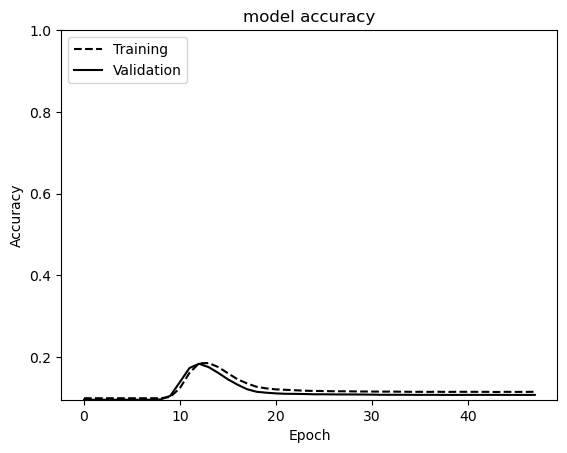

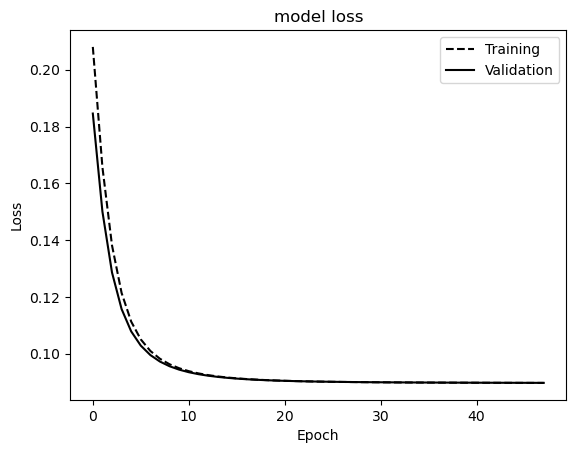

In [13]:
myeval(model, history)

---
### Improving the activation functions

In [14]:
model = Sequential([
    Input(shape=(784,)),
    Dense(16, activation="relu"),
    Dense(16, activation="relu"),
    Dense(num_classes, activation="softmax"),
])

model.summary()

model.compile(
    loss="mean_squared_error",
    optimizer=SGD(),
    metrics=["accuracy"],
)

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_3 (Dense)                 │ (None, 16)             │        12,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │           170 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,002 (50.79 KB)

 Trainable params: 13,002 (50.79 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
%%time

epochs = 48
batch_size = 128
history = model.fit(x_train, y_train,
                    batch_size=batch_size,
                    epochs=epochs,
                    verbose=1,
                    validation_data=(x_val, y_val))

Epoch 1/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.1387 - loss: 0.0897 - val_accuracy: 0.1565 - val_loss: 0.0893
Epoch 2/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1719 - loss: 0.0890 - val_accuracy: 0.1891 - val_loss: 0.0885
Epoch 3/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.1932 - loss: 0.0883 - val_accuracy: 0.2099 - val_loss: 0.0879
Epoch 4/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2080 - loss: 0.0877 - val_accuracy: 0.2223 - val_loss: 0.0873
Epoch 5/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2203 - loss: 0.0871 - val_accuracy: 0.2329 - val_loss: 0.0867
Epoch 6/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2320 - loss: 0.0865 - val_accuracy: 0.2457 - val_loss: 0.0861
Epoch 7/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.2442 - loss: 0.0859 - val_accuracy: 0.2610 - val_loss: 0.0855
Epoch 8/48
391/391 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.2566 - loss: 0.0853 - val_accuracy: 0.

Test loss: 0.03313932195305824
Test accuracy: 0.7824000120162964


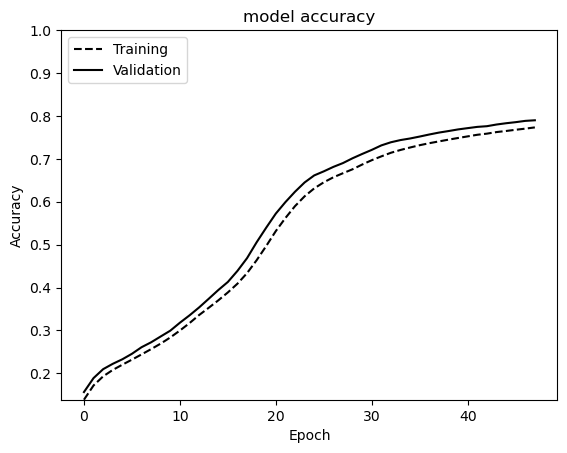

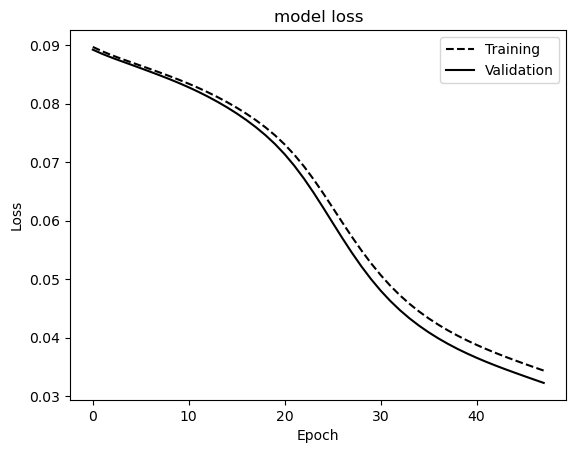

In [16]:
myeval(model, history)

## 5) Exercises

#### Exercise 1: Switch optimizer from SGD to RMSprop and loss function from mean squared error to (categorical) cross-entropy. How does the quality of the network change? Discuss/interpret your results. 

In [17]:
## your code goes here

#### Exercise 2: Increase the number of neurons in the hidden layers to 256 and the epochs to 64. Again, how does the quality of the network change? Discuss/interpret your results.

In [18]:
## your code goes here

# Further "Reading"

Watch the 4th (and so far final) part of the video series on YouTube: <a href="https://www.youtube.com/watch?v=tIeHLnjs5U8">Backpropagation calculus</a>.

In [19]:
# --- EOF ---